In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/CBCT_to_sCT_Project

Mounted at /content/drive
/content/drive/MyDrive/CBCT_to_sCT_Project


In [2]:
!pip install -q SimpleITK pandas matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 12.9 MB/s eta 0:00:00


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk

In [4]:
df = pd.read_csv("data/patient_list.csv")

print("Total patients:", len(df))
print(df.head())
print(df["region"].value_counts())

Total patients: 774
  patient_id region           patient_path                       cbct_path  \
0    2ABA002     AB  data/Task2/AB/2ABA002  data/Task2/AB/2ABA002/cbct.mha   
1    2ABA005     AB  data/Task2/AB/2ABA005  data/Task2/AB/2ABA005/cbct.mha   
2    2ABA006     AB  data/Task2/AB/2ABA006  data/Task2/AB/2ABA006/cbct.mha   
3    2ABA008     AB  data/Task2/AB/2ABA008  data/Task2/AB/2ABA008/cbct.mha   
4    2ABA009     AB  data/Task2/AB/2ABA009  data/Task2/AB/2ABA009/cbct.mha   

                        ct_path                       mask_path  has_cbct  \
0  data/Task2/AB/2ABA002/ct.mha  data/Task2/AB/2ABA002/mask.mha      True   
1  data/Task2/AB/2ABA005/ct.mha  data/Task2/AB/2ABA005/mask.mha      True   
2  data/Task2/AB/2ABA006/ct.mha  data/Task2/AB/2ABA006/mask.mha      True   
3  data/Task2/AB/2ABA008/ct.mha  data/Task2/AB/2ABA008/mask.mha      True   
4  data/Task2/AB/2ABA009/ct.mha  data/Task2/AB/2ABA009/mask.mha      True   

   has_ct  has_mask  
0    True      True  
1   

In [5]:
%%writefile src/preprocessing.py
import numpy as np
import SimpleITK as sitk


def read_mha(path):

    image = sitk.ReadImage(path)
    array = sitk.GetArrayFromImage(image)
    spacing = image.GetSpacing()
    origin = image.GetOrigin()
    direction = image.GetDirection()
    return image, array, spacing, origin, direction


def clip_hu(image, min_hu=-1000, max_hu=1600):

    return np.clip(image, min_hu, max_hu)


def normalize_hu(image, min_hu=-1000, max_hu=1600):

    image = clip_hu(image, min_hu, max_hu)
    image = 2.0 * (image - min_hu) / (max_hu - min_hu) - 1.0
    return image.astype(np.float32)


def denormalize_hu(image_norm, min_hu=-1000, max_hu=1600):

    image = (image_norm + 1.0) / 2.0
    image = image * (max_hu - min_hu) + min_hu
    return image.astype(np.float32)


def prepare_mask(mask):

    return (mask > 0).astype(np.float32)


def apply_mask(image, mask, background_value=-1000):

    image_masked = image.copy()
    image_masked[mask == 0] = background_value
    return image_masked


def get_middle_slice(array):

    z = array.shape[0] // 2
    return array[z], z

Writing src/preprocessing.py


In [6]:
from src.preprocessing import read_mha, normalize_hu, denormalize_hu, prepare_mask, apply_mask

sample = df.iloc[0]

cbct_img, cbct, cbct_spacing, _, _ = read_mha(sample["cbct_path"])
ct_img, ct, ct_spacing, _, _ = read_mha(sample["ct_path"])
mask_img, mask, mask_spacing, _, _ = read_mha(sample["mask_path"])

mask_bin = prepare_mask(mask)

cbct_norm = normalize_hu(cbct)
ct_norm = normalize_hu(ct)

print("Original CBCT range:", cbct.min(), cbct.max())
print("Normalized CBCT range:", cbct_norm.min(), cbct_norm.max())

print("Original CT range:", ct.min(), ct.max())
print("Normalized CT range:", ct_norm.min(), ct_norm.max())

print("Mask values:", np.unique(mask_bin))

Original CBCT range: -1024 682
Normalized CBCT range: -1.0 0.29384616
Original CT range: -1024 1285
Normalized CT range: -1.0 0.75769234
Mask values: [0. 1.]


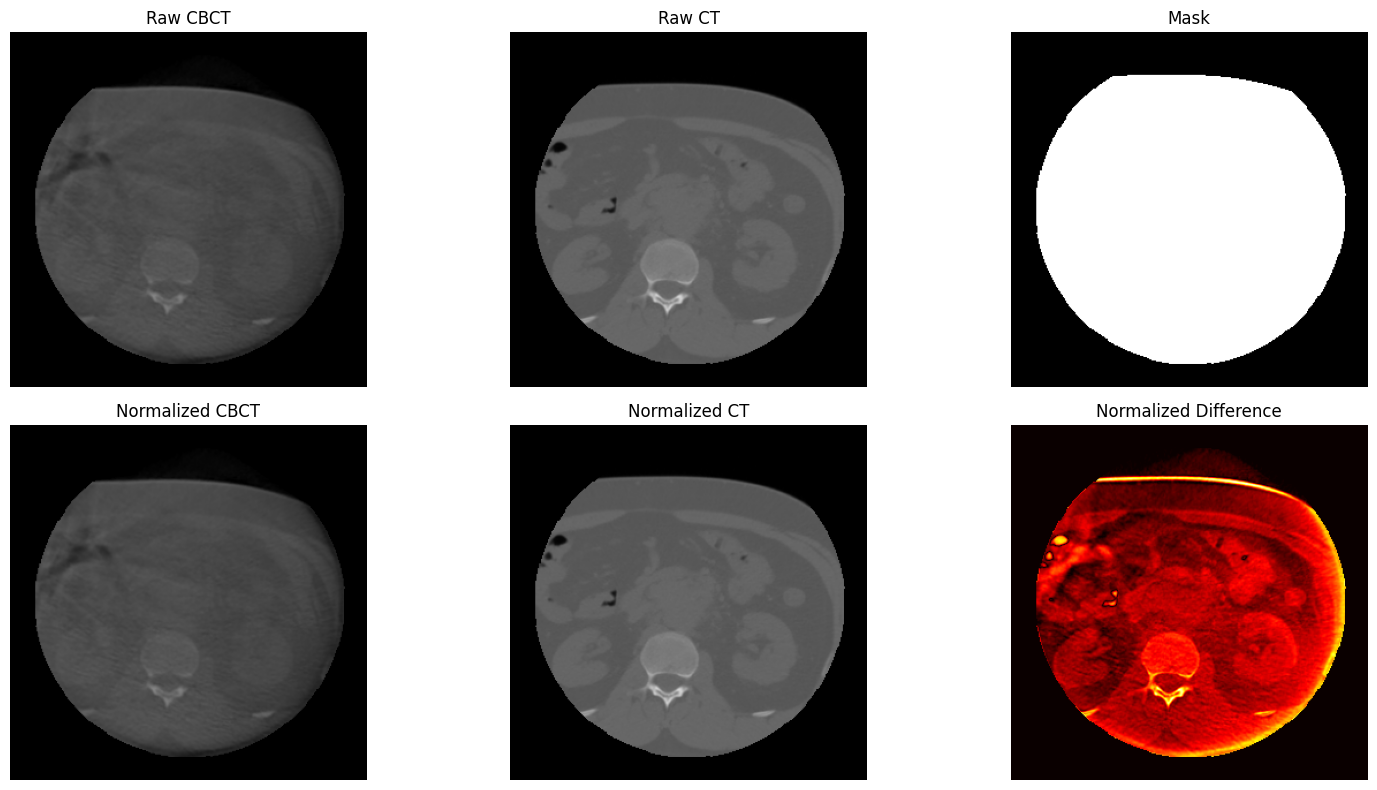

In [7]:
z = cbct.shape[0] // 2

plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.imshow(cbct[z], cmap="gray", vmin=-1000, vmax=1600)
plt.title("Raw CBCT")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(ct[z], cmap="gray", vmin=-1000, vmax=1600)
plt.title("Raw CT")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(mask_bin[z], cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(cbct_norm[z], cmap="gray", vmin=-1, vmax=1)
plt.title("Normalized CBCT")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(ct_norm[z], cmap="gray", vmin=-1, vmax=1)
plt.title("Normalized CT")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(np.abs(cbct_norm[z] - ct_norm[z]), cmap="hot")
plt.title("Normalized Difference")
plt.axis("off")

plt.tight_layout()
plt.show()

Region: AB
Patient: 2ABA002
CBCT original range: -1024 682
CT original range: -1024 1285
CBCT normalized range: -1.0 0.29384616
CT normalized range: -1.0 0.75769234
Mask values: [0. 1.]


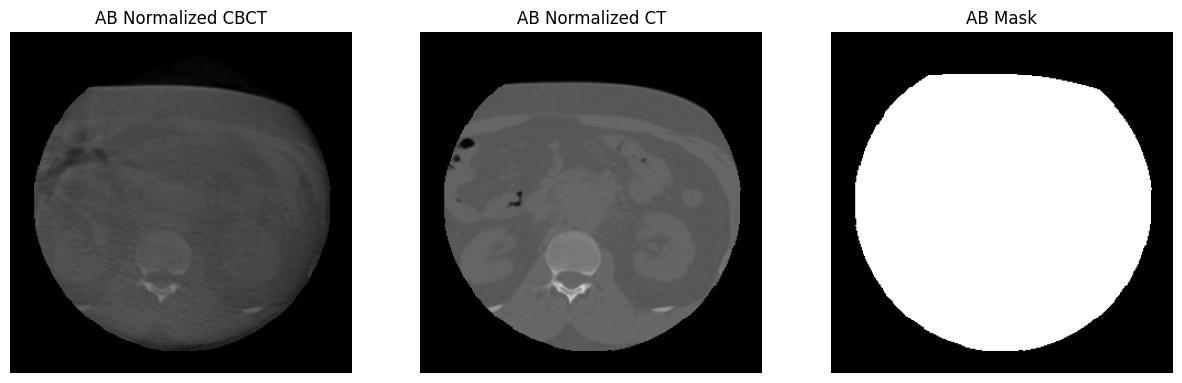

Region: HN
Patient: 2HNA002
CBCT original range: -1024 3071
CT original range: -1024 3071
CBCT normalized range: -1.0 1.0
CT normalized range: -1.0 1.0
Mask values: [0. 1.]


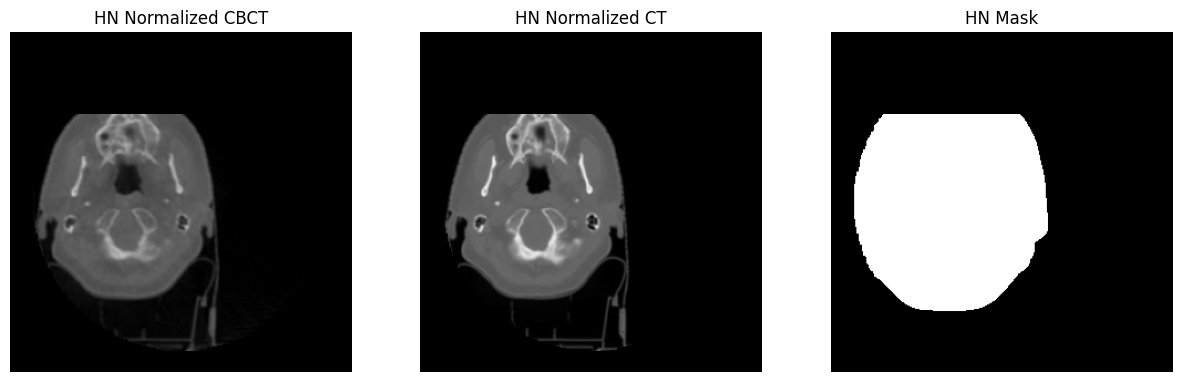

Region: TH
Patient: 2THA005
CBCT original range: -1024 469
CT original range: -1009 1241
CBCT normalized range: -1.0 0.13
CT normalized range: -1.0 0.72384614
Mask values: [0. 1.]


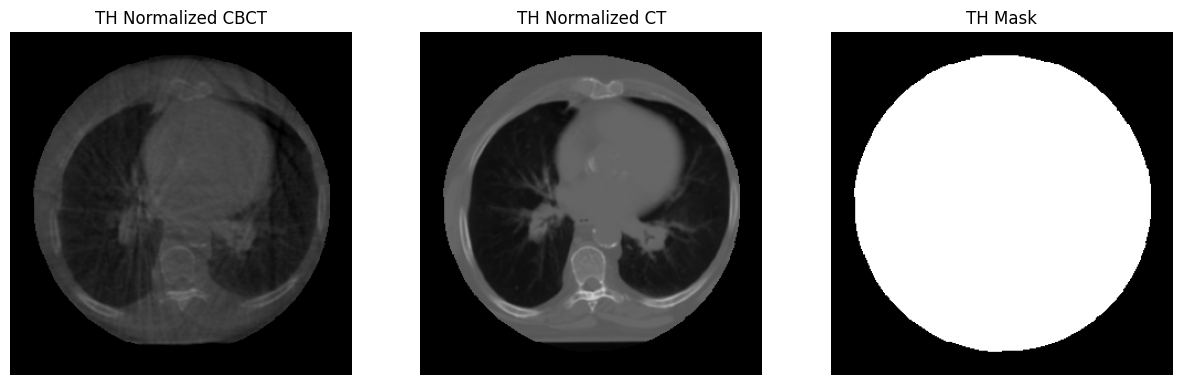

In [8]:
from src.preprocessing import read_mha, normalize_hu, prepare_mask

for region in ["AB", "HN", "TH"]:
    sample = df[df["region"] == region].iloc[0]

    _, cbct, _, _, _ = read_mha(sample["cbct_path"])
    _, ct, _, _, _ = read_mha(sample["ct_path"])
    _, mask, _, _, _ = read_mha(sample["mask_path"])

    cbct_norm = normalize_hu(cbct)
    ct_norm = normalize_hu(ct)
    mask_bin = prepare_mask(mask)

    z = cbct.shape[0] // 2

    print("=" * 60)
    print("Region:", region)
    print("Patient:", sample["patient_id"])
    print("CBCT original range:", cbct.min(), cbct.max())
    print("CT original range:", ct.min(), ct.max())
    print("CBCT normalized range:", cbct_norm.min(), cbct_norm.max())
    print("CT normalized range:", ct_norm.min(), ct_norm.max())
    print("Mask values:", np.unique(mask_bin))

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(cbct_norm[z], cmap="gray", vmin=-1, vmax=1)
    plt.title(f"{region} Normalized CBCT")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(ct_norm[z], cmap="gray", vmin=-1, vmax=1)
    plt.title(f"{region} Normalized CT")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(mask_bin[z], cmap="gray")
    plt.title(f"{region} Mask")
    plt.axis("off")

    plt.show()

In [9]:
os.makedirs("results/figures/preprocessing_examples", exist_ok=True)

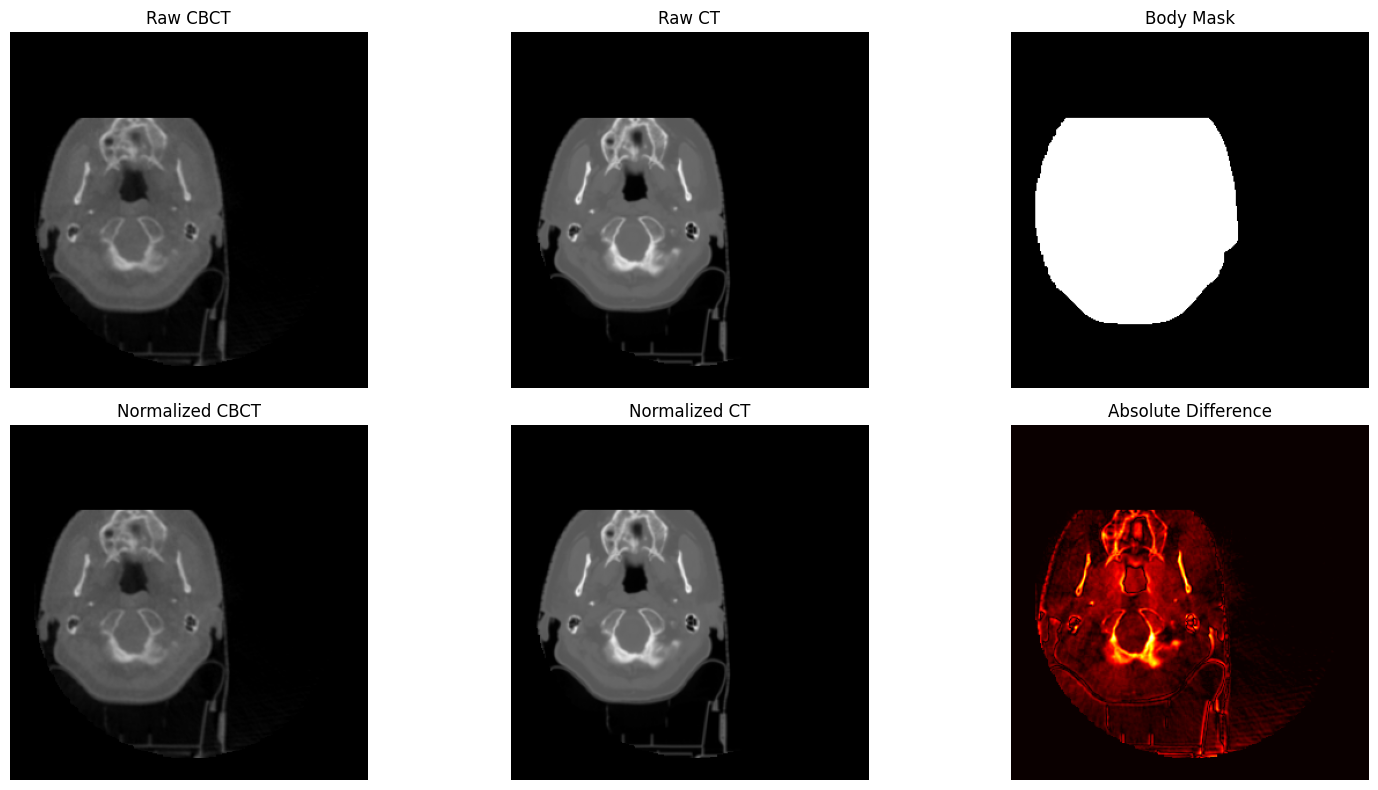

In [10]:
sample = df[df["region"] == "HN"].iloc[0]

_, cbct, _, _, _ = read_mha(sample["cbct_path"])
_, ct, _, _, _ = read_mha(sample["ct_path"])
_, mask, _, _, _ = read_mha(sample["mask_path"])

cbct_norm = normalize_hu(cbct)
ct_norm = normalize_hu(ct)
mask_bin = prepare_mask(mask)

z = cbct.shape[0] // 2

plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.imshow(cbct[z], cmap="gray", vmin=-1000, vmax=1600)
plt.title("Raw CBCT")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(ct[z], cmap="gray", vmin=-1000, vmax=1600)
plt.title("Raw CT")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(mask_bin[z], cmap="gray")
plt.title("Body Mask")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(cbct_norm[z], cmap="gray", vmin=-1, vmax=1)
plt.title("Normalized CBCT")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(ct_norm[z], cmap="gray", vmin=-1, vmax=1)
plt.title("Normalized CT")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(np.abs(cbct_norm[z] - ct_norm[z]), cmap="hot")
plt.title("Absolute Difference")
plt.axis("off")

plt.tight_layout()
plt.savefig("results/figures/preprocessing_examples/h_preprocessing_example.png", dpi=200)
plt.show()

In [11]:
shapes = []

for i, row in df.iterrows():
    _, cbct, spacing, _, _ = read_mha(row["cbct_path"])
    shapes.append({
        "patient_id": row["patient_id"],
        "region": row["region"],
        "z": cbct.shape[0],
        "y": cbct.shape[1],
        "x": cbct.shape[2],
        "spacing_x": spacing[0],
        "spacing_y": spacing[1],
        "spacing_z": spacing[2]
    })

shape_df = pd.DataFrame(shapes)

print(shape_df.head())
print("\nShape summary:")
print(shape_df[["z", "y", "x"]].describe())

print("\nSpacing summary:")
print(shape_df[["spacing_x", "spacing_y", "spacing_z"]].drop_duplicates())

shape_df.to_csv("data/image_shape_summary.csv", index=False)

  patient_id region   z    y    x  spacing_x  spacing_y  spacing_z
0    2ABA002     AB  88  309  310        1.0        1.0        3.0
1    2ABA005     AB  88  309  289        1.0        1.0        3.0
2    2ABA006     AB  87  310  312        1.0        1.0        3.0
3    2ABA008     AB  86  308  315        1.0        1.0        3.0
4    2ABA009     AB  87  313  311        1.0        1.0        3.0

Shape summary:
                z           y           x
count  774.000000  774.000000  774.000000
mean    79.718346  384.275194  385.382429
std      8.320908   80.640983   81.671357
min     49.000000  225.000000  273.000000
25%     73.000000  309.000000  309.000000
50%     81.000000  316.500000  315.000000
75%     87.000000  452.000000  453.000000
max    115.000000  560.000000  560.000000

Spacing summary:
   spacing_x  spacing_y  spacing_z
0        1.0        1.0        3.0
